### EDA

### load dataset

In [6]:
import pandas as pd
data=pd.read_csv('../data/dataset.csv')
print(data)

                                                 subject  \
0      Unvorhergesehener Absturz der Datenanalyse-Pla...   
1                               Customer Support Inquiry   
2                          Data Analytics for Investment   
3                     Krankenhaus-Dienstleistung-Problem   
4                                               Security   
...                                                  ...   
19995     Assistance Needed for IFTTT Docker Integration   
19996        Bitten um Unterstützung bei der Integration   
19997                                                NaN   
19998            Hilfe bei digitalen Strategie-Problemen   
19999  Optimierung Ihrer Datenanalyse-Plattform erlei...   

                                                    body  \
0      Die Datenanalyse-Plattform brach unerwartet ab...   
1      Seeking information on digital strategies that...   
2      I am contacting you to request information on ...   
3      Ein Medien-Daten-Sperrverhalten 

### Inspection du Data : 

In [8]:
data.shape

(20000, 15)

In [9]:
data.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
      dtype='str')

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   18539 non-null  str  
 1   body      19998 non-null  str  
 2   answer    19996 non-null  str  
 3   type      20000 non-null  str  
 4   queue     20000 non-null  str  
 5   priority  20000 non-null  str  
 6   language  20000 non-null  str  
 7   tag_1     20000 non-null  str  
 8   tag_2     19954 non-null  str  
 9   tag_3     19905 non-null  str  
 10  tag_4     18461 non-null  str  
 11  tag_5     13091 non-null  str  
 12  tag_6     7351 non-null   str  
 13  tag_7     3928 non-null   str  
 14  tag_8     1907 non-null   str  
dtypes: str(15)
memory usage: 19.9 MB


In [15]:
print(data.isnull().sum() / len(data) * 100)

subject      7.305
body         0.010
answer       0.020
type         0.000
queue        0.000
priority     0.000
language     0.000
tag_1        0.000
tag_2        0.230
tag_3        0.475
tag_4        7.695
tag_5       34.545
tag_6       63.245
tag_7       80.360
tag_8       90.465
dtype: float64


In [16]:
# Gérer les textes principaux
data['subject'] = data['subject'].fillna('')
data['body'] = data['body'].fillna('')
data['answer'] = data['answer'].fillna('')

# Créer le texte combiné pour NLP
data['text'] = data['subject'] + ' ' + data['body']

# Gérer les tags utiles (< 8% nulls)
for col in ['tag_2', 'tag_3', 'tag_4']:
    data[col] = data[col].fillna('')

# SUPPRIMER les colonnes trop vides (> 30% nulls)
data = data.drop(columns=['tag_5', 'tag_6', 'tag_7', 'tag_8'])

# 6. Vérification finale
print("\n Vérification après nettoyage :")
print(data.isnull().sum())
print(f"\nNombre de colonnes conservées : {data.shape[1]}")
print(f"Colonnes finales : {data.columns.tolist()}")


 Vérification après nettoyage :
subject     0
body        0
answer      0
type        0
queue       0
priority    0
language    0
tag_1       0
tag_2       0
tag_3       0
tag_4       0
text        0
dtype: int64

Nombre de colonnes conservées : 12
Colonnes finales : ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'text']


In [17]:
data=data.drop(columns=['subject', 'body'])

In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   answer    20000 non-null  str  
 1   type      20000 non-null  str  
 2   queue     20000 non-null  str  
 3   priority  20000 non-null  str  
 4   language  20000 non-null  str  
 5   tag_1     20000 non-null  str  
 6   tag_2     20000 non-null  str  
 7   tag_3     20000 non-null  str  
 8   tag_4     20000 non-null  str  
 9   text      20000 non-null  str  
dtypes: str(10)
memory usage: 18.9 MB


In [20]:
data['type'].value_counts()

type
Incident    7978
Request     5763
Problem     4184
Change      2075
Name: count, dtype: int64

In [22]:
data.describe()

,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,text
count,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000
unique,19997,4,10,3,2,148,205,345,482,20000
top,,Incident,Technical Support,medium,en,Technical,Performance,IT,Tech Support,Unvorhergesehener Absturz der Datenanalyse-Pla...
freq,4,7978,5824,8144,11923,5034,2795,3309,3436,1


In [24]:
# find duplicates
data.duplicated().sum()

np.int64(0)

In [31]:
d=len(data['text'].max())
print(d)

464


### imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import ssl

# importation des ressources NLTK   
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    print(" Ressources NLTK OK\n")
except Exception as e:
    print(f" Erreur téléchargement NLTK: {e}")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

### Nettoyage de donnes 


In [ ]:
def clean_text(text):
    """Nettoyage NLP de base"""
    if pd.isna(text) or text == '':
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Suppression ponctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 3. Suppression espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

📥 Téléchargement des ressources NLTK...
✅ Ressources NLTK OK

ANALYSE EXPLORATOIRE

📊 Distribution des types de tickets:
type
Incident    7978
Request     5763
Problem     4184
Change      2075
Name: count, dtype: int64

Pourcentages:
type
Incident    39.890
Request     28.815
Problem     20.920
Change      10.375
Name: proportion, dtype: float64


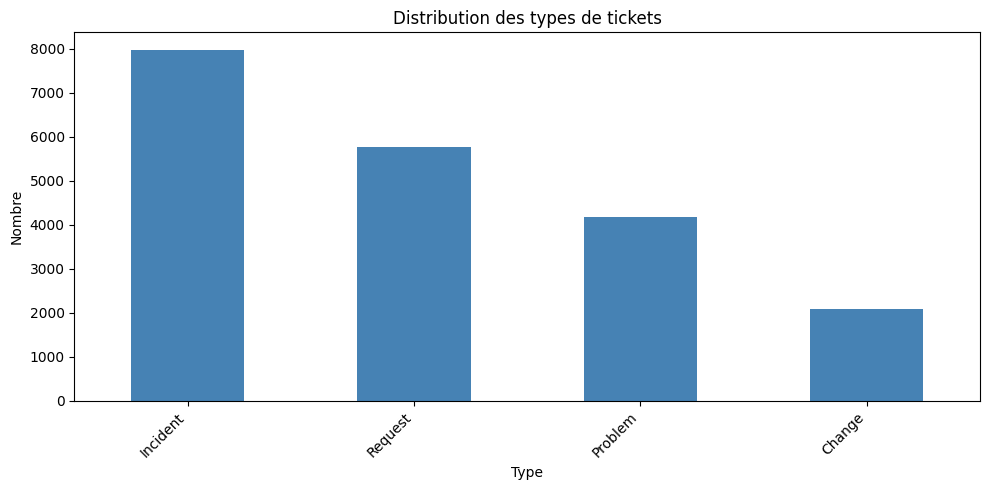


📏 Statistiques de longueur:

Subject:
count    20000.000000
mean        41.594600
std         21.582385
min          0.000000
25%         31.000000
50%         41.000000
75%         53.000000
max        412.000000
Name: subject_length, dtype: float64

Body:
count    20000.00000
mean       394.43810
std        248.26091
min          0.00000
25%        198.00000
50%        357.00000
75%        555.00000
max       2259.00000
Name: body_length, dtype: float64


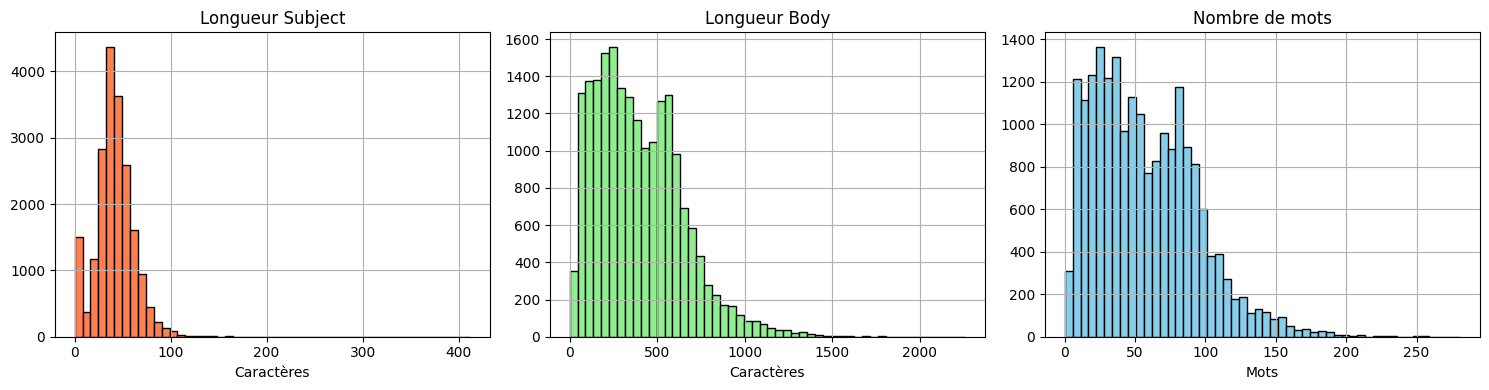


FUSION DES CHAMPS TEXTE
✅ Colonne 'text' créée
Longueur moyenne: 437 caractères

NETTOYAGE NLP

🧹 Nettoyage en cours...
✅ Normalisation et suppression ponctuation OK

📝 Exemple AVANT:
Unvorhergesehener Absturz der Datenanalyse-Plattform Die Datenanalyse-Plattform brach unerwartet ab, da die Speicheroberfläche zu gering war. Ich habe versucht, Laravel 8 und meinen MacBook Pro neu zu

📝 Exemple APRÈS:
unvorhergesehener absturz der datenanalyse plattform die datenanalyse plattform brach unerwartet ab da die speicheroberfläche zu gering war ich habe versucht laravel 8 und meinen macbook pro neu zu st

🔤 Tokenisation...
Langue détectée: english
✅ Tokenisation terminée

🔤 Exemple de tokens:
['unvorhergesehener', 'absturz', 'der', 'datenanalyse', 'plattform', 'die', 'datenanalyse', 'plattform', 'brach', 'unerwartet', 'die', 'speicheroberfläche', 'gering', 'war', 'ich', 'habe', 'versucht', 'laravel', 'und', 'meinen']

📊 Nombre de tokens:
count    20000.000000
mean        44.164550
std        

In [34]:


# ============================================================
# FONCTIONS DE NETTOYAGE
# ============================================================



def tokenize_and_remove_stopwords(text, language='english'):
    """Tokenisation + suppression stopwords"""
    if not text or text == '':
        return []
    
    try:
        # Tokenisation
        tokens = word_tokenize(text)
        
        # Récupérer les stopwords
        stop_words = set(stopwords.words(language))
        
        # Filtrer
        tokens = [
            word for word in tokens 
            if word not in stop_words and len(word) > 2
        ]
        
        return tokens
    
    except LookupError:
        # Si NLTK n'est pas configuré, fallback simple
        print(" NLTK non configuré, utilisation du split simple")
        return text.split()

# ============================================================
# 2. LONGUEUR DES EMAILS
# ============================================================

print("\n📏 Statistiques de longueur:")

df['subject_length'] = df['subject'].fillna('').str.len()
df['body_length'] = df['body'].fillna('').str.len()
df['body_word_count'] = df['body'].fillna('').str.split().str.len()

print("\nSubject:")
print(df['subject_length'].describe())

print("\nBody:")
print(df['body_length'].describe())

# Visualisation
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
df['subject_length'].hist(bins=50, color='coral', edgecolor='black')
plt.title('Longueur Subject')
plt.xlabel('Caractères')

plt.subplot(1, 3, 2)
df['body_length'].hist(bins=50, color='lightgreen', edgecolor='black')
plt.title('Longueur Body')
plt.xlabel('Caractères')

plt.subplot(1, 3, 3)
df['body_word_count'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Nombre de mots')
plt.xlabel('Mots')

plt.tight_layout()
plt.savefig('longueur_emails.png')
plt.show()

# ============================================================
# 3. FUSION DES CHAMPS
# ============================================================

print("\n" + "="*60)
print("FUSION DES CHAMPS TEXTE")
print("="*60)

df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')
df['text'] = df['subject'] + ' ' + df['body']

print(f"✅ Colonne 'text' créée")
print(f"Longueur moyenne: {df['text'].str.len().mean():.0f} caractères")

# ============================================================
# 4. NETTOYAGE NLP
# ============================================================

print("\n" + "="*60)
print("NETTOYAGE NLP")
print("="*60)

# Nettoyage de base
print("\n🧹 Nettoyage en cours...")
df['text_cleaned'] = df['text'].apply(clean_text)
print("✅ Normalisation et suppression ponctuation OK")

# Exemple
print("\n📝 Exemple AVANT:")
print(df['text'].iloc[0][:200])
print("\n📝 Exemple APRÈS:")
print(df['text_cleaned'].iloc[0][:200])

# Tokenisation
print("\n🔤 Tokenisation...")

# Déterminer la langue
if 'language' in df.columns:
    main_language = df['language'].mode()[0]
else:
    main_language = 'english'

language_map = {
    'en': 'english',
    'fr': 'french',
    'de': 'german',
    'es': 'spanish',
    'it': 'italian',
    'pt': 'portuguese'
}

nltk_language = language_map.get(main_language, 'english')
print(f"Langue détectée: {nltk_language}")

# Appliquer tokenisation
df['tokens'] = df['text_cleaned'].apply(
    lambda x: tokenize_and_remove_stopwords(x, nltk_language)
)

print("✅ Tokenisation terminée")

# Exemple tokens
print("\n🔤 Exemple de tokens:")
print(df['tokens'].iloc[0][:20])

# Statistiques
df['num_tokens'] = df['tokens'].apply(len)
print("\n📊 Nombre de tokens:")
print(df['num_tokens'].describe())

# ============================================================
# 5. VÉRIFICATIONS
# ============================================================

print("\n" + "="*60)
print("VÉRIFICATIONS FINALES")
print("="*60)

print("\n❌ Nulls:")
print(df[['text', 'text_cleaned', 'tokens']].isnull().sum())

empty_texts = (df['text_cleaned'].str.len() == 0).sum()
print(f"\n⚠️  Textes vides: {empty_texts}")

if empty_texts > 0:
    df = df[df['text_cleaned'].str.len() > 0].copy()
    print(f"✅ {empty_texts} lignes vides supprimées")

# Sauvegarder
df.to_csv('tickets_cleaned.csv', index=False)
print("\n💾 Sauvegardé: tickets_cleaned.csv")

print("\n" + "="*60)
print("✅ ÉTAPE 1 TERMINÉE")
print("="*60)
print(f"Tickets traités: {len(df)}")
print(f"Types uniques: {df['type'].nunique()}")
print(f"Tokens moyens: {df['num_tokens'].mean():.0f}")